## Assignment 1  - Group A1 4
by: Veronika Lietavcova, Julia Papiernik, Thorri Elis Halldoruson

In [1]:
import pandas as pd


df = pd.read_csv("merged_incidents.csv")
df["Incident Date"] = pd.to_datetime(df["Incident Date"], format="%Y/%m/%d")
df["Year"] = df["Incident Date"].dt.year
min_date = df["Incident Date"].min()
max_date = df["Incident Date"].max()

first_year = min_date.year
last_year = max_date.year

if min_date > pd.Timestamp(f"{first_year}-01-01"):
    df = df[df["Year"] != first_year]
if max_date < pd.Timestamp(f"{last_year}-12-31"):
    df = df[df["Year"] != last_year]

# Drop rows with missing key values
df = df.dropna(subset=["Incident Category", "Incident Date", "Longitude", "Latitude"])


## Assignment 1.1: Temporal Overview
> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025. 
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.

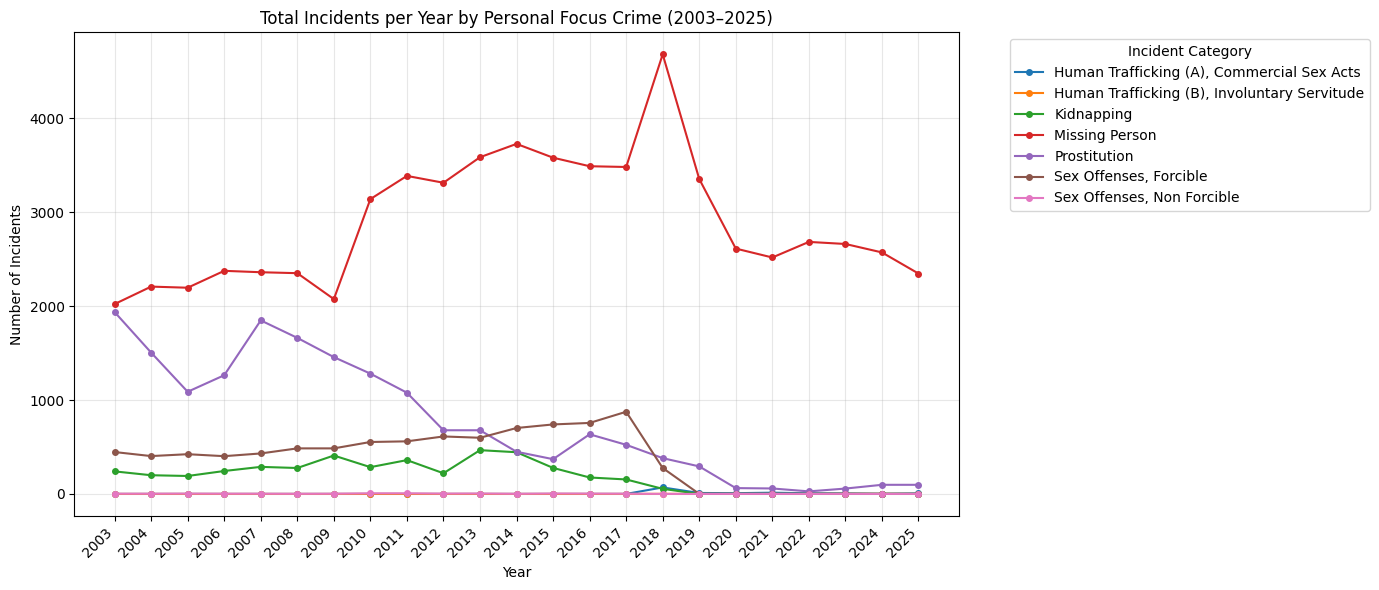

In [2]:
import matplotlib.pyplot as plt

# Count incidents per year for each category
yearly_counts = df.groupby(["Year", "Incident Category"]).size().unstack(fill_value=0)

# Plot
fig, ax = plt.subplots(figsize=(14, 6))
for category in yearly_counts.columns:
    ax.plot(yearly_counts.index, yearly_counts[category], marker="o", markersize=4, label=category.title())

ax.set_xlabel("Year")
ax.set_ylabel("Number of Incidents")
ax.set_title("Total Incidents per Year by Personal Focus Crime (2003–2025)")
ax.set_xticks(range(2003, 2026))
ax.set_xticklabels(range(2003, 2026), rotation=45, ha="right")
ax.legend(title="Incident Category", bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

**Notable features:**

**The Missing Person Spike (2017–2019)** 

There is a sharp increase in Missing Person reports starting in 2017, reaching a peak in 2018, and staying high through 2019 before a sudden drop in 2020. Possible explanations could include increased public awareness or changes in reporting practices. The drop in 2020 may be due to the COVID-19 pandemic, which could have led to fewer people going out meaning fewer opportunities for individuals to go missing.

**The Long-Term Decline in Prostitution** 

Prostitution reports show a dramatic, steady decline from nearly 2,000 cases in 2007 to almost zero by 2022. This could be due to a combination of factors, such as increased law enforcement efforts, shifting the focus of law enforcement resources, or the rise of online platforms that may have changed how prostitution is conducted and reported.

---
# Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from: Week 3, Exercises 2.1 and 2.2.*


 > * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
 A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.

In [3]:
# Define personal focus crimes
personal_focus_crimes = ['human trafficking (a), commercial sex acts', 'human trafficking (b), involuntary servitude', 'missing person', 'kidnapping', ]

df['Police District'] = df['Police District'].str.upper()

# Get all unique police districts
districts = df['Police District'].unique()
districts = [d for d in districts if pd.notna(d)]

# Initialize dictionary to store results
crime_profiles = {}

# Compute P(crime) for each crime type (city-wide probability)
total_crimes = len(df)
p_crime = {}
for crime in personal_focus_crimes:
    p_crime[crime] = len(df[df['Incident Category'] == crime]) / total_crimes

# Compute P(crime|district) / P(crime) for each district and crime
for district in districts:
    district_df = df[df['Police District'] == district]
    total_district_crimes = len(district_df)
    
    crime_profiles[district] = {}
    
    for crime in personal_focus_crimes:
        crime_in_district = len(district_df[district_df['Incident Category'] == crime])
        p_crime_given_district = crime_in_district / total_district_crimes if total_district_crimes > 0 else 0
        ratio = p_crime_given_district / p_crime[crime] if p_crime[crime] > 0 else 0
        crime_profiles[district][crime] = ratio

# Convert to DataFrame
profiles_df = pd.DataFrame(crime_profiles).T
profiles_df = profiles_df[personal_focus_crimes]

> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)

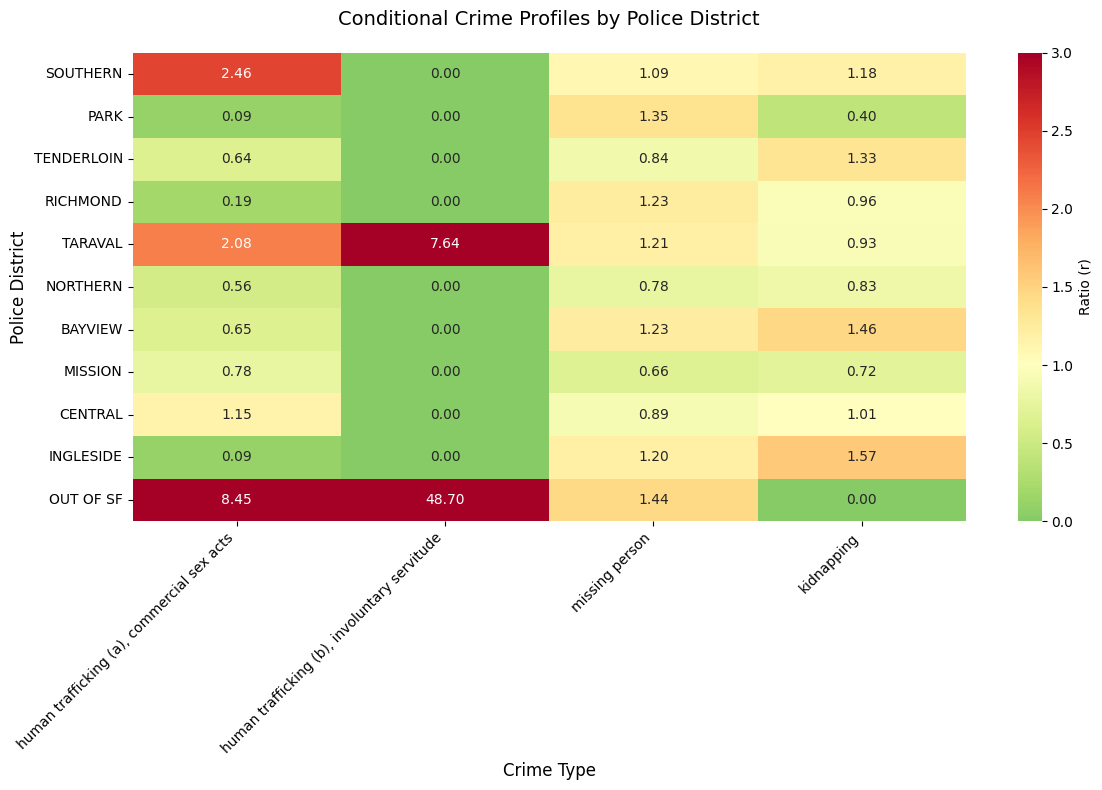

<Figure size 640x480 with 0 Axes>

In [6]:
import seaborn as sns
import matplotlib.pyplot as pl

plt.figure(figsize=(12, 8))
sns.heatmap(profiles_df, annot=True, fmt='.2f', cmap='RdYlGn_r', 
            center=1, vmin=0, vmax=3, cbar_kws={'label': 'Ratio (r)'})
plt.title('Conditional Crime Profiles by Police District', 
          fontsize=14, pad=20)
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Police District', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
plt.savefig("district_heatmap.png", dpi=150, bbox_inches="tight")

> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

Looking at the heatmap, the district Taraval jumps out in human trafficking. While kidnapping and missing persons are pretty close to the city average (around 0.93 and 1.21), the ratio for "involuntary servitude" is 7.65, which is huge. 

This might be because Taraval is a quiet residential area. In such areas, involuntary servitude might be easier to hide in private homes or small local businesses.

---
## Assignment 1.3: Visualizing Distributions

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.

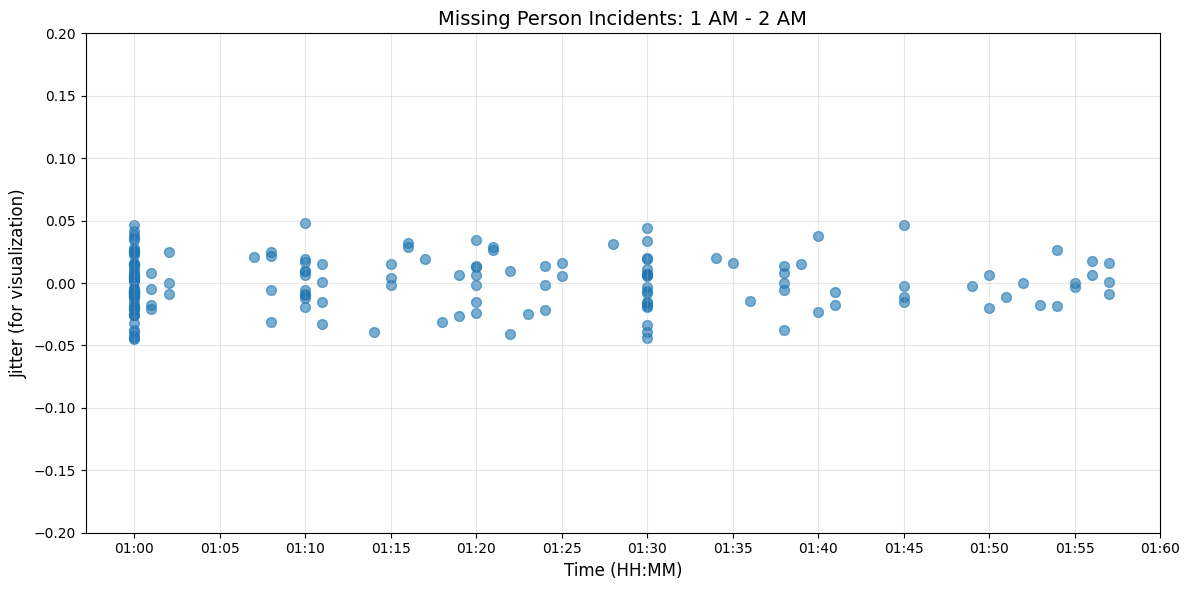

In [ ]:
# personal crime 
one_focus = 'missing person'
#time interval: 1 month to 6 months
time_interval = 6
df_one_focus = df[df['Incident Category'] == one_focus].copy()
df_one_focus['Incident Date'] = pd.to_datetime(df_one_focus['Incident Date'])
df_one_focus = df_one_focus[df_one_focus['Incident Date'] >= pd.to_datetime('2023-01-01') - pd.DateOffset(months=time_interval)]

import matplotlib.pyplot as plt
import numpy as np

# Combine incident date and time into one datetime column
df_one_focus['Incident DateTime'] = pd.to_datetime(df_one_focus['Incident Date'].astype(str) + ' ' + df_one_focus['Incident Time'].astype(str))

# Extract hour
df_one_focus['hour'] = df_one_focus['Incident DateTime'].dt.hour
df_one_focus = df_one_focus[df_one_focus['hour'] == 1]  # 1 AM to 2 AM

# Extract minute for x-axis
df_one_focus['minute'] = df_one_focus['Incident DateTime'].dt.minute
df_one_focus['second'] = df_one_focus['Incident DateTime'].dt.second

# Create jitter plot
fig, ax = plt.subplots(figsize=(12, 6))

# Add vertical jitter to y-axis for visibility
jitter = np.random.normal(0, 0.02, size=len(df_one_focus))
ax.scatter(df_one_focus['minute'] + df_one_focus['second']/60, jitter, alpha=0.6, s=50)

# Format x-axis to show time like 01:00, 01:05, etc.
hour = 1  # We're looking at 1 AM
x_ticks = np.arange(0, 61, 5)  # Every 5 minutes
x_labels = [f'{hour:02d}:{int(m):02d}' for m in x_ticks]
ax.set_xticks(x_ticks)
ax.set_xticklabels(x_labels)

ax.set_xlabel('Time (HH:MM)', fontsize=12)
ax.set_ylabel('Jitter (for visualization)', fontsize=12)
ax.set_title('Missing Person Incidents: 1 AM - 2 AM', fontsize=14)
ax.set_ylim(-0.2, 0.2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?

We believe that the data is recorded on reasonable detailed time interval, but we see quite a big concentration around 1:30 and 1 am. Furthemore, we can also see tendency on rounding around 5 and 10 minutes intervals. However, due to severity of this category "missing person" , it also makes sense that the data is also spread across all minutes, though with higher sparsity. This could be also caused how data is collected, automated solution will provide with exact timestamp, where a human filled report might be a subject to rounding.

Another interesting aspect is that the first half of the hour examines much higher density than the ladder part(1:30 to 2:00).

> **Part B — Probability plot**
>* Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (scipy.stats.probplot is your friend here.)

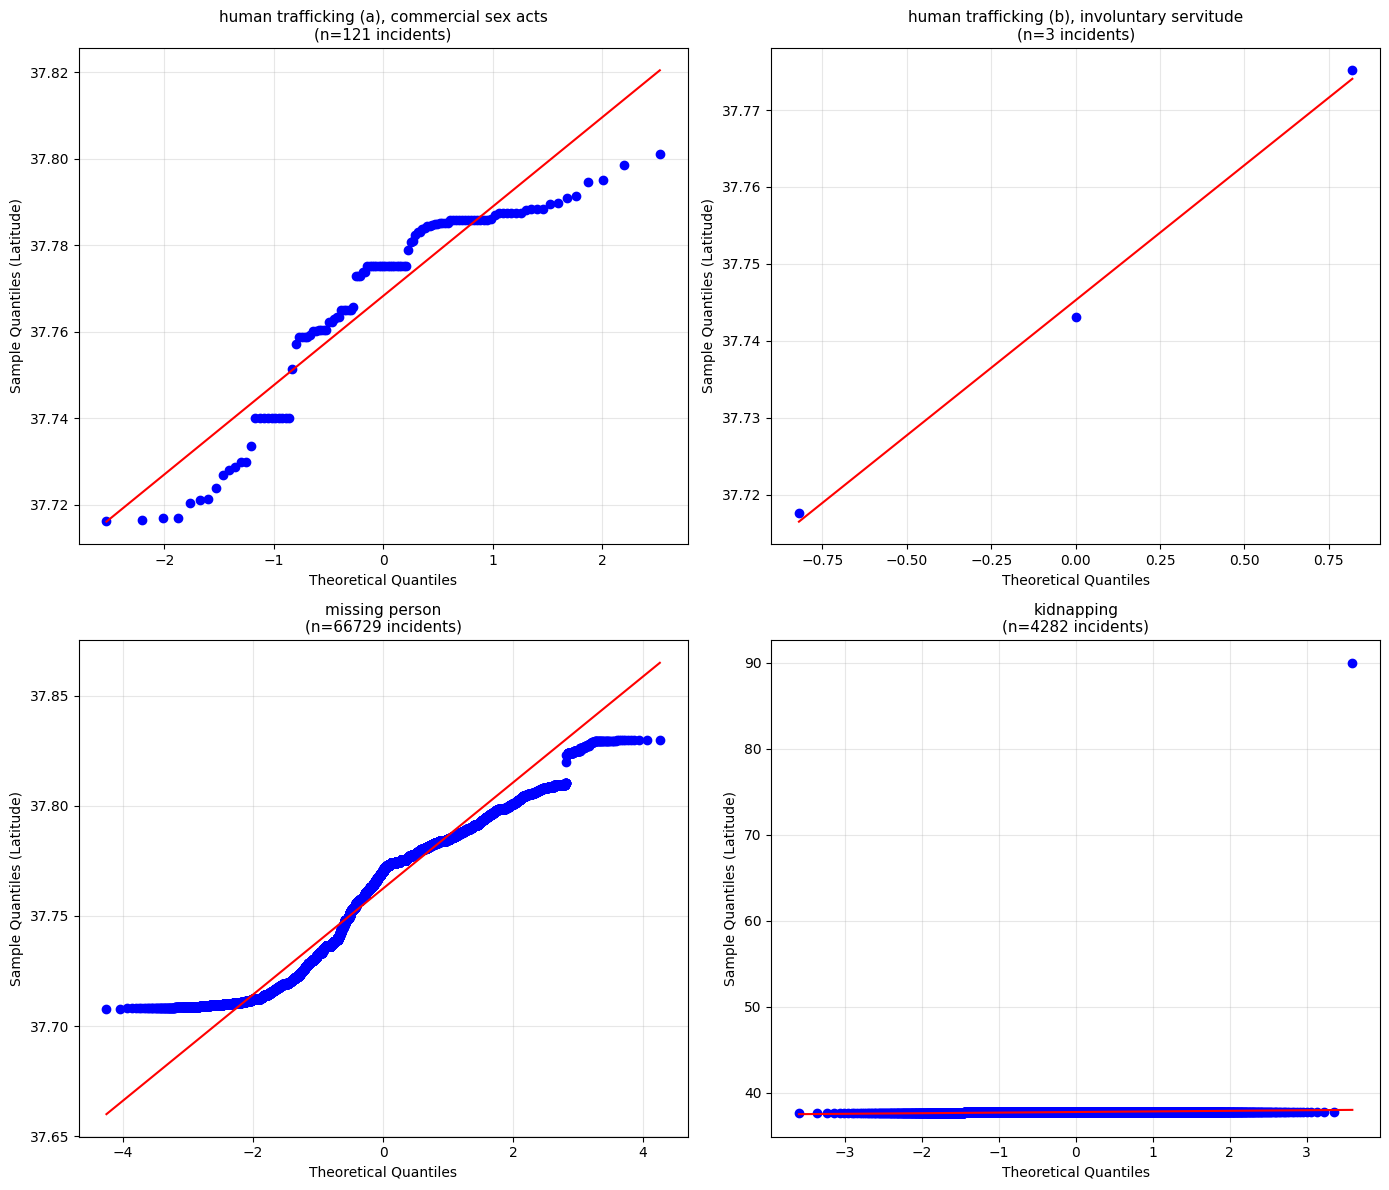

In [ ]:
from scipy import stats 

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Personal focus crimes
personal_focus_crimes = [
    'human trafficking (a), commercial sex acts', 
    'human trafficking (b), involuntary servitude',
    'missing person',
    'kidnapping',
]

# Filter out rows with missing latitude values
df_geo = df[df['Latitude'].notna()].copy()

# Create QQ plots for each crime type
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, crime in enumerate(personal_focus_crimes):
    ax = axes[idx]
    
    # Filter data for this crime type
    crime_data = df_geo[df_geo['Incident Category'] == crime]['Latitude'].values
    
    # Create QQ plot
    stats.probplot(crime_data, dist="norm", plot=ax)
    
    ax.set_title(f'{crime}\n(n={len(crime_data)} incidents)', fontsize=11)
    ax.set_xlabel('Theoretical Quantiles', fontsize=10)
    ax.set_ylabel('Sample Quantiles (Latitude)', fontsize=10)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


>* What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?

We are comparing against a normal (Gaussian) distribution. If the dots sat perfectly on the red line, it would mean crime is spread out in a smooth, predictable "bell curve" from the north to the south of the city. The plots don't follow the line, but have big steps. This tells us that crime isn't spread out evenly across the city, but clustered in specific neighborhoods. The flat floors represent quiet areas with almost no incidents, while the jumps show the intense hotspots where most crimes are concentrated. This tells us that the geography of crime in SF is defined by specific blocks and busy streets.

> **Part C — Box plots of time-of-day**
>* For each of your Personal Focus Crimes, extract the time-of-day of every incident.
>* Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.

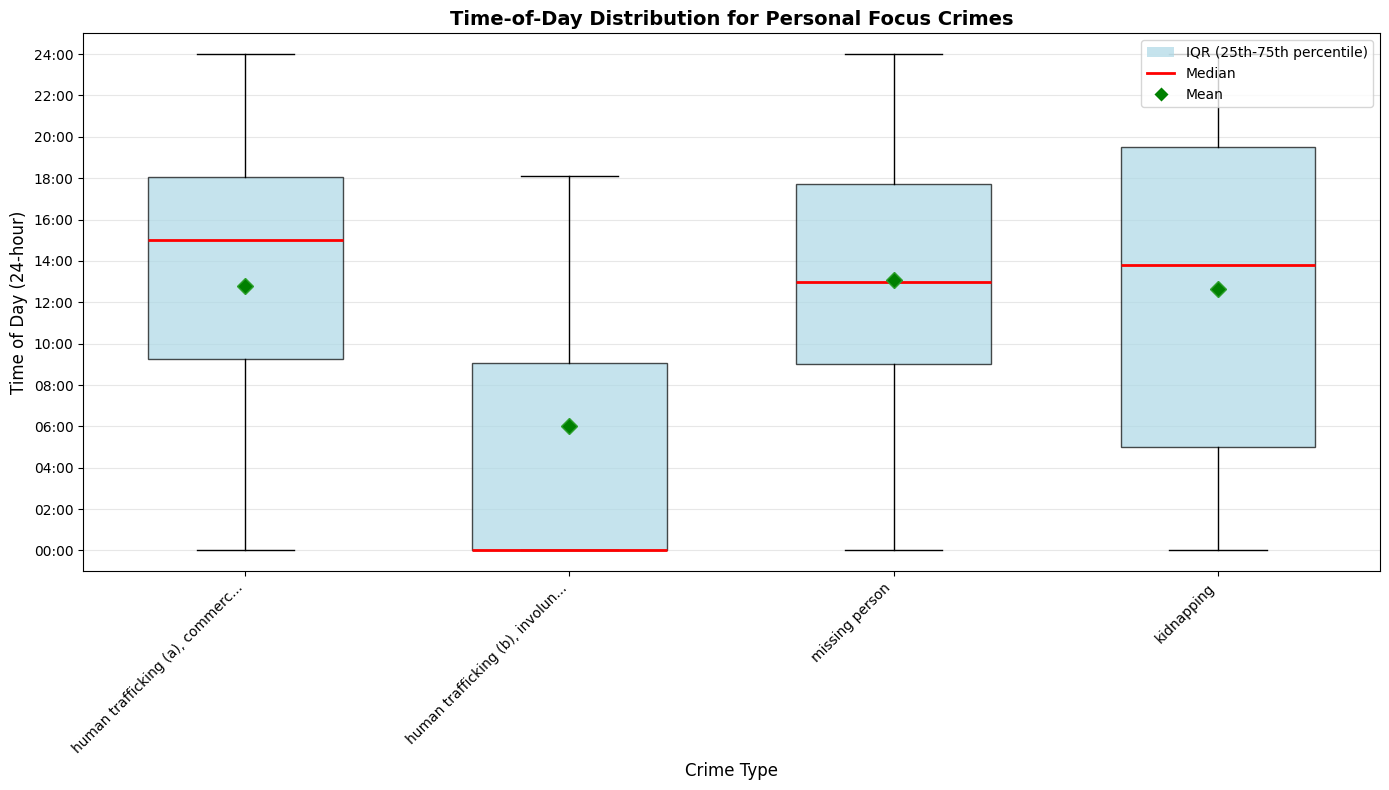

In [ ]:
# Part C - Box Plots

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


# Prepare data: extract hour from Incident Time
df_time = df[df['Incident Time'].notna()].copy()
df_time['Incident DateTime'] = pd.to_datetime(df_time['Incident Time'], format='%H:%M', errors='coerce')
df_time['hour_decimal'] = df_time['Incident DateTime'].dt.hour + df_time['Incident DateTime'].dt.minute / 60

# Filter for personal focus crimes
df_time_focus = df_time[df_time['Incident Category'].isin(personal_focus_crimes)].copy()

# Create box plots
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for box plot
data_to_plot = [df_time_focus[df_time_focus['Incident Category'] == crime]['hour_decimal'].dropna() 
                for crime in personal_focus_crimes]

# Create box plot
bp = ax.boxplot(data_to_plot, labels=personal_focus_crimes, patch_artist=True, 
                widths=0.6, showmeans=True,
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                meanprops=dict(marker='D', markerfacecolor='green', markersize=8))

ax.set_ylabel('Time of Day (24-hour)', fontsize=12)
ax.set_xlabel('Crime Type', fontsize=12)
ax.set_title('Time-of-Day Distribution for Personal Focus Crimes', fontsize=14, fontweight='bold')
ax.set_xticklabels([crime[:30] + '...' if len(crime) > 30 else crime for crime in personal_focus_crimes], 
                    rotation=45, ha='right', fontsize=10)

# Set y-axis to show hours (0-24)
ax.set_yticks(range(0, 25, 2))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
ax.set_ylim(-1, 25)
ax.grid(True, axis='y', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='lightblue', alpha=0.7, label='IQR (25th-75th percentile)'),
    plt.Line2D([0], [0], color='red', linewidth=2, label='Median'),
    plt.Line2D([0], [0], marker='D', color='w', markerfacecolor='green', 
               markersize=8, label='Mean')
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

>* What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?

Most of these crimes happen during the day, primarily between 12:00 and 16:00. Labor trafficking is the outlier, happening much earlier. These are primarily business hour crimes. The box plot doesnt handles midnight well. It computes 11:59 PM and 12:01 AM as being 24 hours apart instead of minutes. This makes the graph stretch out and look larger than it is for any night-crimes.

>* Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

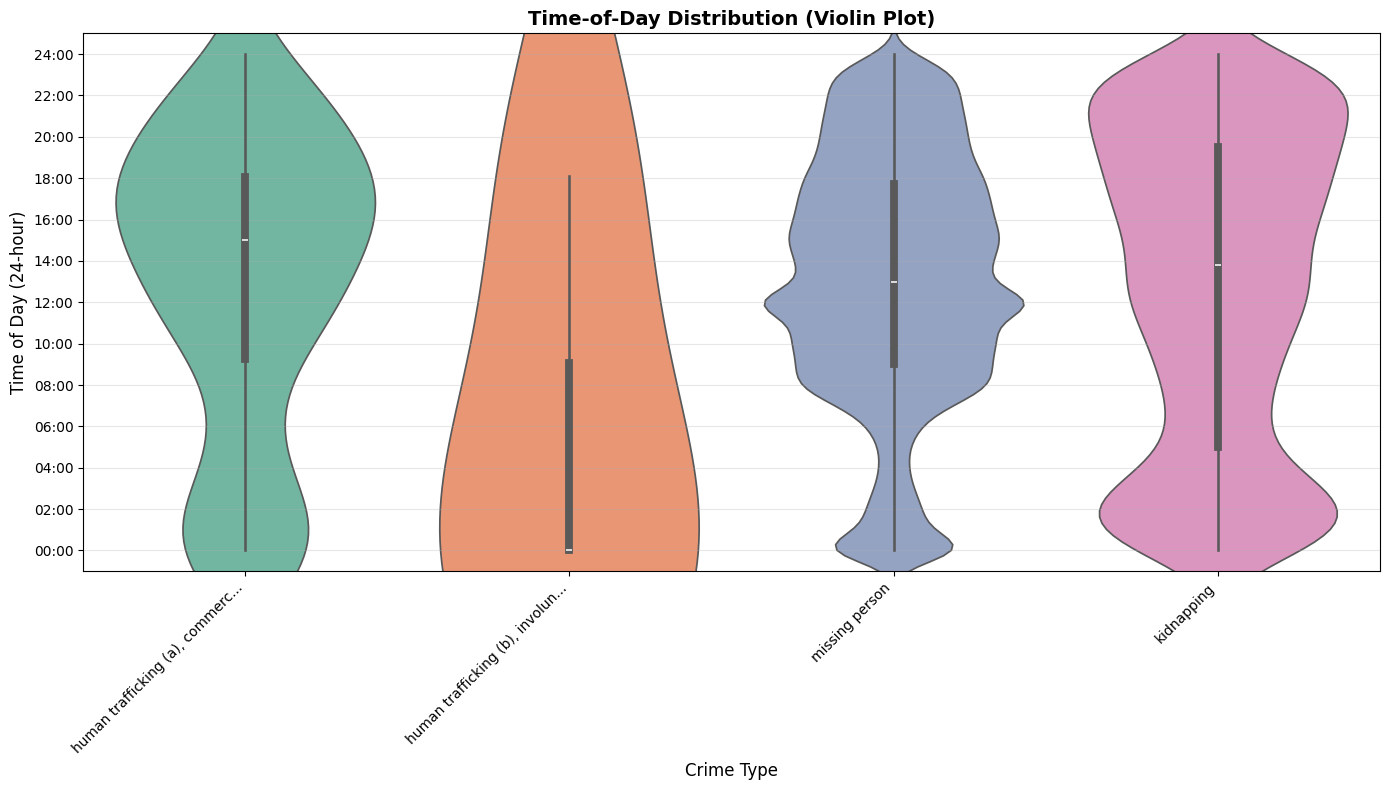

In [ ]:
# Part C - Violin Plot Alternative

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


import seaborn as sns

# Create violin plots as an alternative visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data in format for seaborn
plot_data = []
for crime in personal_focus_crimes:
    crime_hours = df_time_focus[df_time_focus['Incident Category'] == crime]['hour_decimal'].dropna()
    for hour in crime_hours:
        plot_data.append({'Crime Type': crime, 'Hour': hour})

plot_df = pd.DataFrame(plot_data)

# Create violin plot
sns.violinplot(data=plot_df, x='Crime Type', y='Hour', ax=ax, palette='Set2', inner='box')

ax.set_ylabel('Time of Day (24-hour)', fontsize=12)
ax.set_xlabel('Crime Type', fontsize=12)
ax.set_title('Time-of-Day Distribution (Violin Plot)', fontsize=14, fontweight='bold')
ax.set_xticklabels([crime[:30] + '...' if len(crime) > 30 else crime for crime in personal_focus_crimes], 
                    rotation=45, ha='right', fontsize=10)

# Format y-axis
ax.set_yticks(range(0, 25, 2))
ax.set_yticklabels([f'{h:02d}:00' for h in range(0, 25, 2)])
ax.set_ylim(-1, 25)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Most of these crimes peak during the day, like missing persons and kidnapping clustering around noon, while labor trafficking peaks sharply in the morning. Using a violin plot will show the actual shape of the data. For example, the two distinct peak times for kidnapping, which a box plot would just smudge together. The box plot also fails at midnight because it treats 11:59 PM and 12:01 AM as being 24 hours apart, making late-night data look artificially streched out.




---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.

In [ ]:
import numpy as np
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    """Great circle distance between two points (in km)."""
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return 6371 * c  # km

# Most common crime
most_common = df["Incident Category"].value_counts().idxmax()

# Filter to most common crime
df_crime = df[df["Incident Category"] == most_common].copy()

# Remove outliers
df_crime = df_crime[(df_crime["Latitude"] < 50) & (df_crime["Longitude"] < -122)]

# Derive bounding box from filtered data
lat_min = df_crime["Latitude"].min()
lat_max = df_crime["Latitude"].max()
lon_min = df_crime["Longitude"].min()
lon_max = df_crime["Longitude"].max()

# Use haversine to figure out how many ~100m bins we need
# Multiply by 10 since haversine returns km and we want bins per 100m
n_lat_bins = int(round(haversine(lon_min, lat_min, lon_min, lat_max) * 10))
n_lon_bins = int(round(haversine(lon_min, lat_min, lon_max, lat_min) * 10))

> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).

In [ ]:
# Use np.histogram2d to count incidents per cell
counts, lat_edges, lon_edges = np.histogram2d(
    df_crime["Latitude"].values,
    df_crime["Longitude"].values,
    bins=[n_lat_bins, n_lon_bins],
    range=[[lat_min, lat_max], [lon_min, lon_max]]
)

# Flatten to 1D array of incident counts per cell
cell_counts = counts.flatten().astype(int)

# Build a DataFrame with one row per cell (all cells, including empty ones)
import pandas as pd

rows = []
for i in range(n_lat_bins):
    for j in range(n_lon_bins):
        rows.append({
            "Lat bin center": round((lat_edges[i] + lat_edges[i+1]) / 2, 5),
            "Lon bin center": round((lon_edges[j] + lon_edges[j+1]) / 2, 5),
            "Incident count": int(counts[i, j])
        })

cell_df = pd.DataFrame(rows).sort_values("Incident count", ascending=False).reset_index(drop=True)

> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.

In [ ]:
# N(k) = number of cells that have exactly k incidents
k_max = cell_counts.max()
k_values = np.arange(0, k_max + 1)
N_k = np.array([np.sum(cell_counts == k) for k in k_values])

> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.

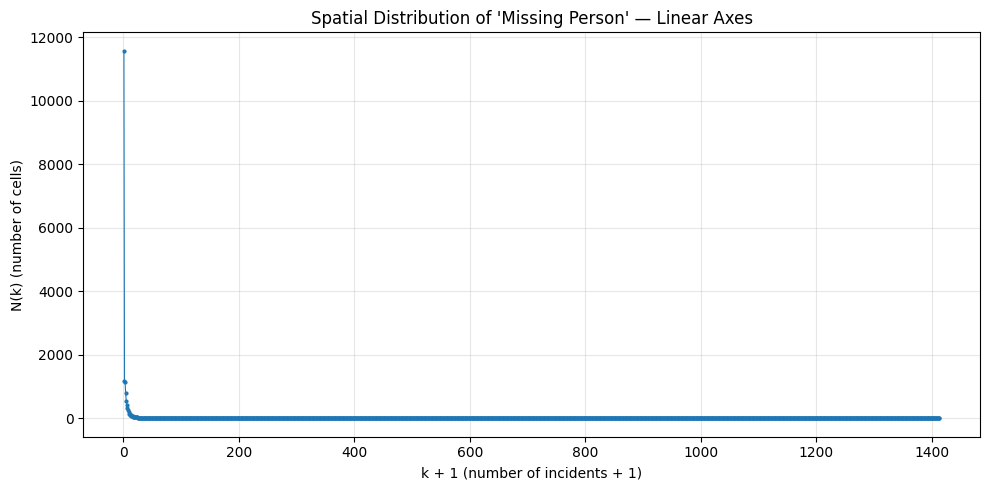

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_values + 1, N_k, "o-", markersize=2, linewidth=0.8)
ax.set_xlabel("k + 1 (number of incidents + 1)")
ax.set_ylabel("N(k) (number of cells)")
ax.set_title(f"Spatial Distribution of '{most_common.title()}' — Linear Axes")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.

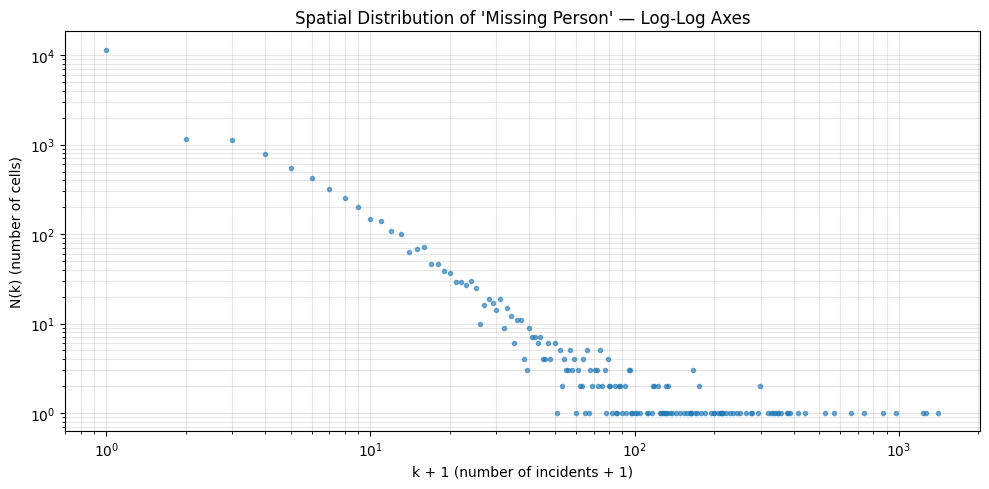

In [ ]:
# Filter out k values where N(k) == 0 (can't plot log of 0)
mask = N_k > 0

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(k_values[mask] + 1, N_k[mask], "o", markersize=3, alpha=0.6)
ax.set_xlabel("k + 1 (number of incidents + 1)")
ax.set_ylabel("N(k) (number of cells)")
ax.set_title(f"Spatial Distribution of '{most_common.title()}' — Log-Log Axes")
ax.grid(True, alpha=0.3, which="both")
plt.tight_layout()
plt.show()

> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?

Yes, the "Missing Person" crime follows a power-law spatial distribution. This can be observed from the log-log plot where the data points form an approximately straight line, indicating that the frequency of cells with k incidents decreases as a power of k. In a power-law distribution, we would expect to see many cells with few incidents and a few cells with many incidents, which is consistent with the observed pattern.

> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

If a crime is concentrated in just a few cells, it implies that neighborhood-level statistics can be very missleading. Becouse of this the "average block" doesn't tell us anything useful. When we calculte the average, it mathematically spreads out the crime evenly across all blocks and it might suggest that on every street in this area these is a mild crime problem when in reality, most blocks or streets would have no incidents, while a few blocks would have many incidents or even one specific block or corner could have all of theses incidents. Therefore, averages fail to tell us what a normal street is actually like, and they can give us a very distorted picture of the crime situation in a neighborhood.

---
## Assignment 1.5: Regression and Correlation

Which of your Personal Focus Crimes share the most similar weekly rhythm — and which are completely out of sync?

In [ ]:
personal_focus_crimes =[
    'human trafficking (a), commercial sex acts', 
    'human trafficking (b), involuntary servitude',
    'missing person',
    'kidnapping',
]

> * For each selected crime type, compute the total number of incidents for each of the **168 hours of the week** (i.e., Monday 00:00–01:00, Monday 01:00–02:00, ..., Sunday 23:00–00:00). Each crime type will give you a vector of 168 values.

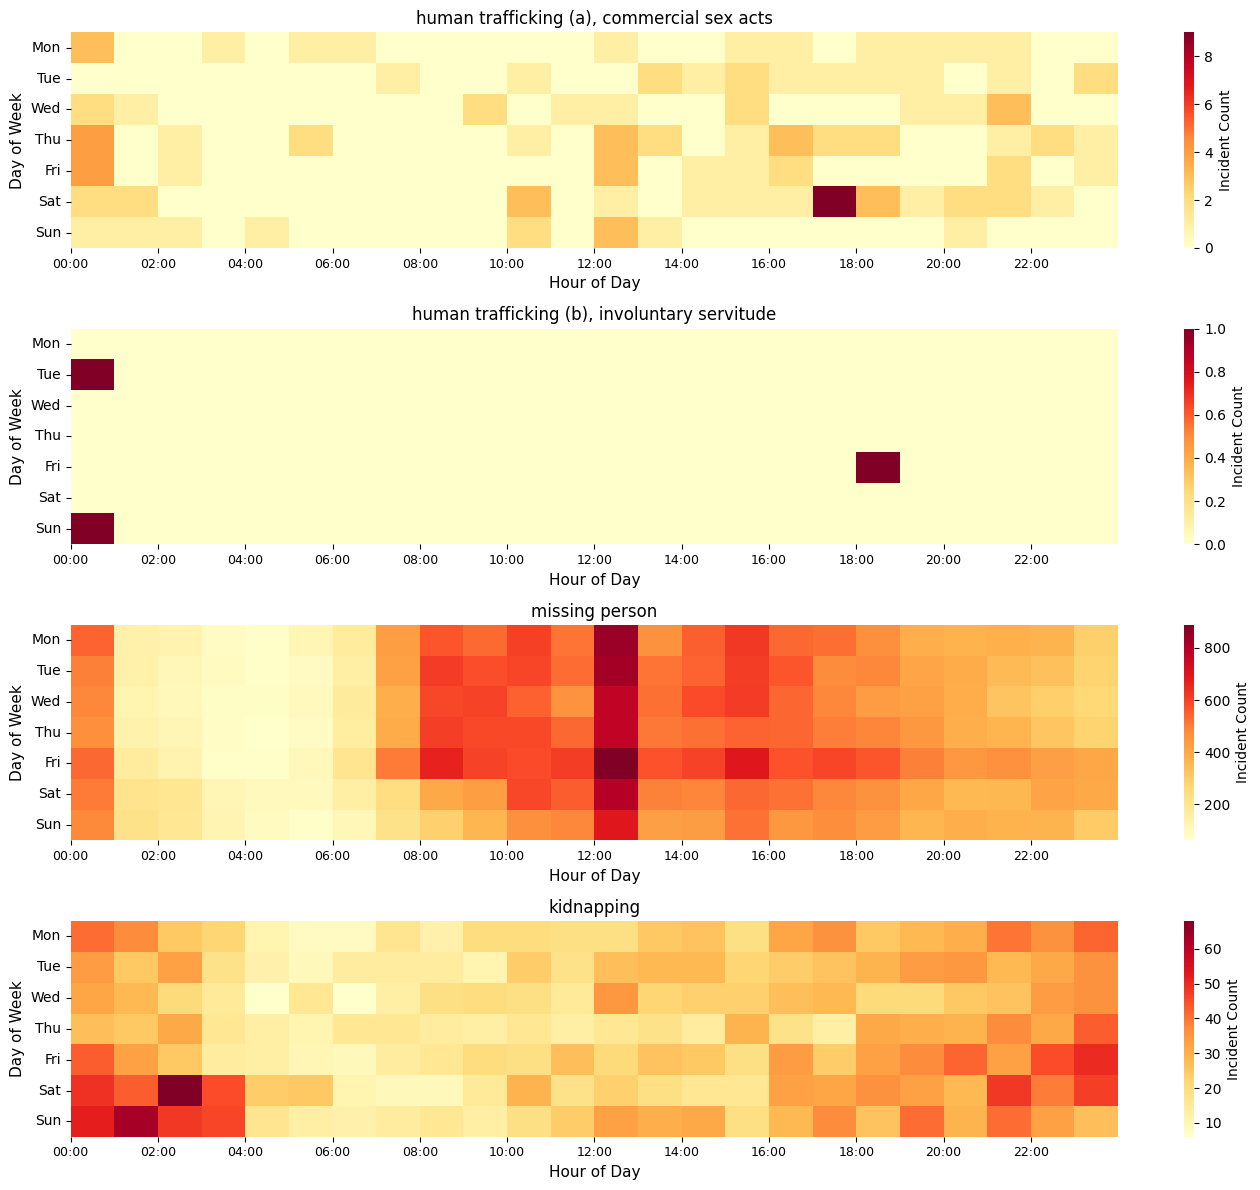

In [ ]:
# Map day of week strings to numbers (0=Monday, 6=Sunday)
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
df['day_of_week'] = df['Incident Day of Week'].map(day_map)

# Extract hour from Incident Time
df['hour_of_day'] = pd.to_datetime(df['Incident Time'], format='%H:%M').dt.hour

# Create week_hour index (0-167): Monday 00:00 = 0, Sunday 23:00 = 167
df['week_hour'] = df['day_of_week'] * 24 + df['hour_of_day']

# For each crime type, compute the count for each of the 168 hours
crime_vectors = {}
for crime in personal_focus_crimes:
    crime_df = df[df['Incident Category'] == crime]
    # Count incidents for each week_hour (0-167)
    counts = crime_df['week_hour'].value_counts().reindex(range(168), fill_value=0).sort_index()
    crime_vectors[crime] = counts.values


#----------------------------------------------JUST FOR VISUALIZATION OF THE HEATMAPS --------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

# Create a separate heatmap for each crime type
fig, axes = plt.subplots(len(personal_focus_crimes), 1, figsize=(14, 3*len(personal_focus_crimes)))

days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for idx, crime in enumerate(personal_focus_crimes):
    # Reshape 168 hours into 7 days x 24 hours
    heatmap_data = crime_vectors[crime].reshape(7, 24)
    
    ax = axes[idx] if len(personal_focus_crimes) > 1 else axes
    sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Incident Count'})
    
    # Set y-axis labels to days
    ax.set_yticklabels(days, rotation=0, fontsize=10)
    
    # Set x-axis labels for hours
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(0, 24, 2)], fontsize=9)
    
    ax.set_xlabel('Hour of Day', fontsize=11)
    ax.set_ylabel('Day of Week', fontsize=11)
    ax.set_title(f'{crime}', fontsize=12)

plt.tight_layout()
plt.show()

> * **Scatterplot matrix**: Create a grid of pairwise scatterplots — one panel per pair of crime types, with one crime on each axis and each of the 168 hours as a point. Label each panel clearly with the two crime types being compared.

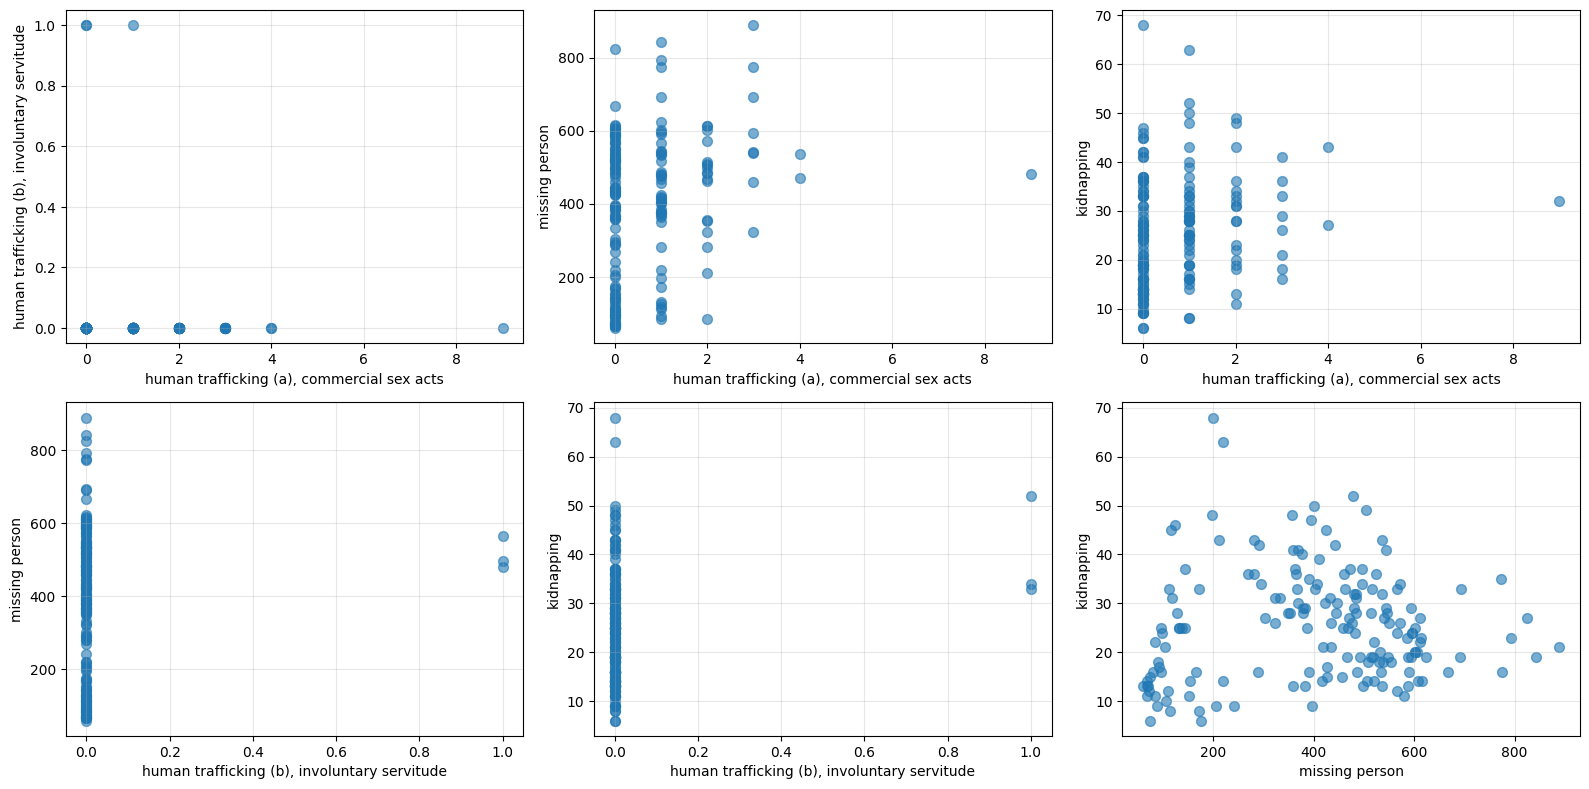

In [ ]:
from itertools import combinations

# Get all pairs of crime types
crime_pairs = list(combinations(personal_focus_crimes, 2))
n_pairs = len(crime_pairs)

# Arrange subplots in a grid
n_cols = 3
n_rows = (n_pairs + n_cols - 1) // n_cols 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()  # Flatten for easier indexing

# Create a scatterplot for each pair of crime types
for idx, (crime1, crime2) in enumerate(crime_pairs):
    ax = axes[idx]
    x = crime_vectors[crime1]
    y = crime_vectors[crime2]
    ax.scatter(x, y, alpha=0.6, s=50)
    ax.set_xlabel(crime1, fontsize=10)
    ax.set_ylabel(crime2, fontsize=10)
    #ax.set_title(f'{crime1} vs\n{crime2}', fontsize=11, loc='left')
    ax.grid(True, alpha=0.3)

for idx in range(n_pairs, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

> * **Linear regression**: Using the closed-form equations from Week 4 (not a library), fit a regression line $y = ax + b$ to each pair and add it to the relevant panel:
>   $$a = \frac{\sum_i x_i y_i - N\langle x\rangle\langle y\rangle}{\sum_i x_i^2 - N\langle x\rangle^2}, \qquad b = \langle y \rangle - a\langle x \rangle$$

In [ ]:
def linear_regression(x, y):
    """
    Fit a regression line y = ax + b using closed-form equations.
    
    a = (sum(x*y) - N*mean(x)*mean(y)) / (sum(x^2) - N*mean(x)^2)
    b = mean(y) - a*mean(x)
    """
    N = len(x)
    x_mean = np.mean(x)
    y_mean = np.mean(y)
    
    # Compute a
    numerator = np.sum(x * y) - N * x_mean * y_mean
    denominator = np.sum(x**2) - N * x_mean**2
    a = numerator / denominator
    
    # Compute b
    b = y_mean - a * x_mean
    
    return a, b

> * **$R^2$**: Write a function to compute $R^2$ for each pair and display the value on each panel. You can check your implementation against `sklearn` if you like.

In [ ]:
# Function to compute R-squared
def r_squared(x, y, a, b):
    """Compute R-squared for goodness of fit."""
    y_pred = a * x + b
    ss_res = np.sum((y - y_pred)**2)  # Residual sum of squares
    ss_tot = np.sum((y - np.mean(y))**2)  # Total sum of squares
    return 1 - (ss_res / ss_tot)

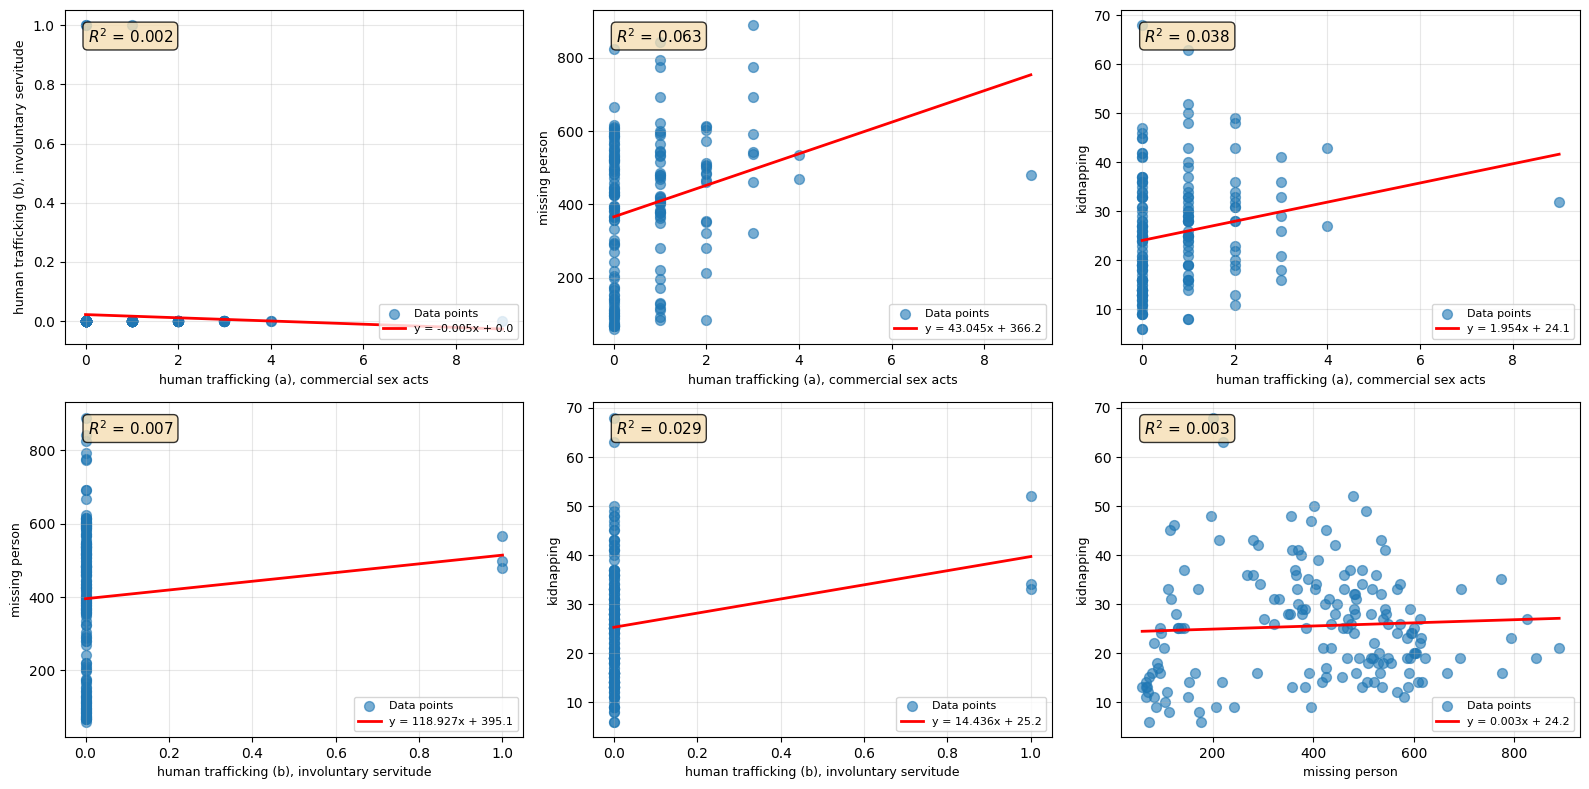

In [ ]:
# Update scatterplot matrix with regression lines
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, (crime1, crime2) in enumerate(crime_pairs):
    ax = axes[idx]
    x = crime_vectors[crime1]
    y = crime_vectors[crime2]
    ax.scatter(x, y, alpha=0.6, s=50, label='Data points')
    a, b = linear_regression(x, y)
    r2 = r_squared(x, y, a, b)
    x_line = np.array([x.min(), x.max()])
    y_line = a * x_line + b
    ax.plot(x_line, y_line, 'r-', linewidth=2, label=f'y = {a:.3f}x + {b:.1f}')
    
    # Labels and formatting
    ax.set_xlabel(crime1, fontsize=9)
    ax.set_ylabel(crime2, fontsize=9)
    ax.text(0.05, 0.95, f'$R^2$ = {r2:.3f}', transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, loc='lower right')

for idx in range(n_pairs, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

> * Looking at your results: which pair of crimes is **most correlated**? Which is **least correlated**? Does the answer match your intuition? Why might two crime types share a weekly rhythm — or not?

$R^2$ tells us about the proportion of the variance in the dependent variable (y) that is predictable from an independent variable (x). Usually it ranges from 0 to 1, where 1 explains all variability of the data. When it is 0, none of the variability is explained, such that the independent variable provides no predictive power. 

From the calculation, we can see in all pairs, the $R^2$  is very low, signalling that there is nearly no linear relationship between each category.  Judging by the different nature of these crimes (human trafficking is rarely connected to missing person) these values are expected. 

The highest $R^2$ is between "missing person" and "human trafficking(a), commercial sex acts", we also see a steep slope in this graph, this shows us that steep slope does not directly means strong relationship. The 0.063 $R^2$  is statistically "weak", explaining only 6.3 % of the variance. Even though the link is statistically weak, the connection between these 2 from a purely sociological perspective makes sense, since runaway person, might end up as a subject to human trafficking and one engaging in these activities might find themself in dangerous environments and could be more likely to go missing. However, person missing,  might be reported days later and wise versa, which is what is likely to caused this incosistency from intuition. 

The lowerst $R^2$ is between "human trafficking (a), commercial sex acts" and "human trafficking (b), involuntary servitude". From a purely conceptually perspective, we would actually expect the opposite result, given that the crimes are very similar, spike in theory could increase spike in the other, however the data does not seem to point to this direction. 

The data does not suggest a very strong weekly rythm correlation, however from the heatmaps created, there is a tendency of some activities such as human traficking to happen during weekends and evening hours. We however have to point out when a data is collected, If we assume that data about human trafficking is collected when a case has been completed, that might be reported during the day, despite the fact that the actual crime happened during different hours. Another important aspect is that in the "missing person" category, there is a description of "person found" or "person missing" and the data is not filter on this, meaning that the data is pulluted by daily reporting of found people, instead of purely missing people events. 

## Contributions



Contributions of individual members: 

Veronika Lietavcova (250695): 1.3A, 1.5

Julia Papiernik (254743): 1.1, 1.4

Thorri Elis Halldoruson (252362): 1.2, 1.3B, 1.3C